In [2]:
import pandas as pd

# Load the dataset
df = pd.read_excel('/content/dataset_10_retail_return_risk.csv.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,order_value,item_count,discount_pct,customer_return_rate,delivery_days,category_risk,target
0,167.23,0,56.44,47.39,9,5,1
1,252.38,0,77.75,18.12,3,2,1
2,43.00,2,36.74,68.95,37,5,0
3,116.83,3,75.15,41.31,2,5,0
4,217.44,2,35.47,72.17,49,5,1


In [3]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Description:')
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_value           1000 non-null   float64
 1   item_count            1000 non-null   int64  
 2   discount_pct          1000 non-null   float64
 3   customer_return_rate  1000 non-null   float64
 4   delivery_days         1000 non-null   int64  
 5   category_risk         1000 non-null   int64  
 6   target                1000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 54.8 KB

DataFrame Description:


,order_value,item_count,discount_pct,customer_return_rate,delivery_days,category_risk,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,190.187980,2.983000,50.428700,50.751580,29.714000,3.003000,0.50000
std,167.621449,1.711619,19.369209,19.730003,17.439792,1.419509,0.50025
min,11.900000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000
25%,88.992500,2.000000,36.760000,37.540000,15.000000,2.000000,0.00000
50%,146.120000,3.000000,49.555000,51.370000,30.000000,3.000000,0.50000
75%,237.515000,4.000000,63.997500,64.295000,45.000000,4.000000,1.00000
max,2659.390000,9.000000,100.000000,100.000000,60.000000,5.000000,1.00000


In [4]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets
# Using a stratify split since the target variable is perfectly balanced (50/50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 6)
X_test shape: (200, 6)
y_train shape: (800,)
y_test shape: (200,)


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Accuracy: 0.6700
Precision: 0.6545
Recall: 0.7200
F1-Score: 0.6857
ROC-AUC: 0.7307


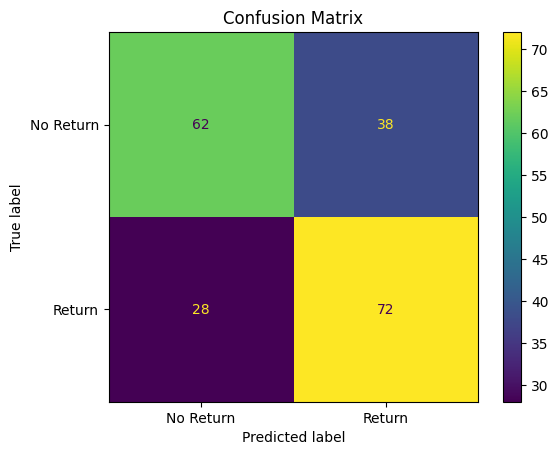

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cmd_obj = ConfusionMatrixDisplay(cm, display_labels=['No Return', 'Return'])
cmd_obj.plot()
plt.title('Confusion Matrix')
plt.show()

In [8]:
import pandas as pd

# Get the feature names
feature_names = X.columns

# Get the coefficients of the Logistic Regression model
coefficients = model.coef_[0]

# Create a DataFrame to display feature importance
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value for better understanding of magnitude of influence
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

display(coef_df.drop('Abs_Coefficient', axis=1))

,Feature,Coefficient
4,delivery_days,0.642939
5,category_risk,-0.606948
2,discount_pct,0.530346
0,order_value,0.494533
1,item_count,-0.431170
3,customer_return_rate,-0.345517


## Limitations, Generalization Risks, and Possible Improvements

### Limitations:
1.  **Model Simplicity:** Logistic Regression is a linear model and might not capture complex non-linear relationships between predictors and the target variable. More sophisticated models could potentially yield better performance.
2.  **Feature Engineering:** The current model uses raw features. Further feature engineering (e.g., interaction terms, polynomial features, or creating new features from existing ones) could uncover more predictive power.
3.  **Data Size:** With 1,000 rows, the dataset is relatively small. The model's performance and generalization might improve with more data.
4.  **Static Data:** The analysis is based on a snapshot of data. Customer behavior, return rates, and retail dynamics can change over time, making the model potentially less relevant without retraining on fresh data.
5.  **Interpretability of `customer_return_rate`:** The negative coefficient for `customer_return_rate` is counter-intuitive and needs further investigation to understand its true relationship with return risk.

### Generalization Risks:
1.  **Overfitting to Current Data:** Although a train-test split was used, the model's performance might not generalize well to completely new, unseen data if the current dataset is not fully representative of the overall population of orders.
2.  **Domain Shift:** If business conditions change (e.g., new product categories, different return policies, economic shifts), the model's predictive accuracy could degrade significantly.
3.  **Bias in Data:** If the training data contains biases (e.g., certain customer segments or product types are underrepresented), the model's predictions might be unfair or inaccurate for those segments.

### Possible Improvements:
1.  **Advanced Algorithms:** Explore other classification algorithms such as Gradient Boosting Machines (e.g., XGBoost, LightGBM), Random Forests, or Support Vector Machines, which can often capture more complex patterns.
2.  **Hyperparameter Tuning:** Systematically tune the hyperparameters of the Logistic Regression model (e.g., regularization strength C) to optimize its performance.
3.  **Feature Selection/Importance:** Implement more rigorous feature selection techniques to identify the most impactful features and potentially remove noise.
4.  **Interaction Terms:** Investigate potential interaction effects between features (e.g., `discount_pct` and `order_value`).
5.  **Collect More Data:** Expanding the dataset with more historical orders and potentially more relevant features could significantly improve model robustness and performance.
6.  **Anomaly Detection:** Implement anomaly detection techniques to identify unusual orders that might be particularly prone to returns, which the current model might not effectively capture.
7.  **Threshold Optimization:** The default classification threshold of 0.5 might not be optimal. Depending on the business cost of false positives vs. false negatives, the threshold could be adjusted to optimize for specific business objectives (e.g., higher recall if minimizing missed returns is critical).

This concludes the analysis for the retail return risk prediction project. The Logistic Regression model provides a baseline for understanding the drivers of return risk, and the identified areas for improvement offer clear paths for developing a more robust and accurate solution.